In [1]:
# ---------------- Import Libraries ----------------
import numpy as np  # for numerical operations
import pandas as pd  # for data handling
import matplotlib.pyplot as plt  # for plotting
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ---------------- Load Dataset ----------------
dataset = pd.read_csv('Wine.csv')  # load dataset
X = dataset.iloc[:, 0:13].values  # features
y = dataset.iloc[:, 13].values  # target

In [3]:
# ---------------- Train-Test Split ----------------
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)  # split data

In [4]:
# ---------------- Feature Scaling ----------------
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)  # scale training data
X_test = sc.transform(X_test)  # scale test data

In [5]:
# ---------------- LDA ----------------
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=2)  # reduce to 2 components using class information
X_train = lda.fit_transform(X_train, y_train)  # fit LDA using X and y
X_test = lda.transform(X_test)  # transform test data

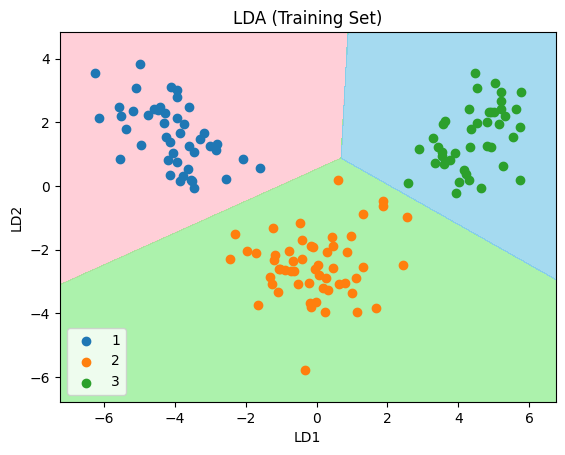

In [7]:
# ---------------- Visualization (Training Set) ----------------
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train  # use transformed data

X1, X2 = np.meshgrid(np.arange(X_set[:,0].min()-1, X_set[:,0].max()+1, 0.01),
                     np.arange(X_set[:,1].min()-1, X_set[:,1].max()+1, 0.01))  # grid

from sklearn.linear_model import LogisticRegression
temp_model = LogisticRegression(max_iter=1000)
temp_model.fit(X_train, y_train)  # temp model for plotting

plt.contourf(X1, X2, temp_model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(('pink','lightgreen','skyblue')))  # decision boundary

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set==j,0], X_set[y_set==j,1], label=j)  # plot points

plt.title('LDA (Training Set)')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend()
plt.show()

The LDA plot shows three clearly separated groups, indicating that LDA has effectively transformed the data to maximize class separation.

In [8]:
# ---------------- Model Evaluation Function ----------------
from sklearn.metrics import accuracy_score

def model_accuracy(model, X_train, y_train, X_test, y_test):  # train and evaluate
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)

In [9]:
# ---------------- Models ----------------
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

acclog=[]; accsvml=[]; accsvmnl=[]; accknn=[]; accnav=[]; accdes=[]; accrf=[]

# run models
acclog.append(model_accuracy(LogisticRegression(max_iter=1000), X_train, y_train, X_test, y_test))  # logistic
accsvml.append(model_accuracy(SVC(kernel='linear'), X_train, y_train, X_test, y_test))  # svm linear
accsvmnl.append(model_accuracy(SVC(kernel='rbf'), X_train, y_train, X_test, y_test))  # svm nonlinear
accknn.append(model_accuracy(KNeighborsClassifier(n_neighbors=5), X_train, y_train, X_test, y_test))  # knn
accnav.append(model_accuracy(GaussianNB(), X_train, y_train, X_test, y_test))  # naive bayes
accdes.append(model_accuracy(DecisionTreeClassifier(), X_train, y_train, X_test, y_test))  # decision tree
accrf.append(model_accuracy(RandomForestClassifier(n_estimators=100), X_train, y_train, X_test, y_test))  # random forest

In [10]:
# ---------------- Result Table ----------------
result = pd.DataFrame(index=['LDA'], columns=['Logistic','SVMl','SVMnl','KNN','Navie','Decision','Random'])  # table

result.loc['LDA','Logistic'] = acclog[0]
result.loc['LDA','SVMl'] = accsvml[0]
result.loc['LDA','SVMnl'] = accsvmnl[0]
result.loc['LDA','KNN'] = accknn[0]
result.loc['LDA','Navie'] = accnav[0]
result.loc['LDA','Decision'] = accdes[0]
result.loc['LDA','Random'] = accrf[0]

In [11]:
result

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
LDA,1.0,0.972222,1.0,0.972222,0.972222,0.972222,1.0


After applying LDA, most models achieved very high accuracy (up to 1.0), showing that LDA has clearly separated the classes and improved model performance.